In [10]:
from utils import *
NOTEBOOK_ID = '09'

# analyze protein descriptors from eggnog-mapper

In [11]:
ACTIVATOR_MIN = 1.0934882543970346 # maximum activator threshold value from notebook 05
data_df = pd.read_csv(f'{ANALYSIS_DIR}/experimental_data_fitted.csv')
data_df = data_df[data_df['tile_ID'].apply(lambda x: len(x.split('-')) > 1)] # remove controls

tile_df = pd.read_csv(f'{TILE_DIR}/viral_tiles.csv')
protein_df = pd.read_csv(f'{TILE_DIR}/viral_proteins_clustered90.csv')

cols = ['query','seed_ortholog','evalue','score','eggNOG_OGs','max_annot_lvl','COG_category','Description','Preferred_name','GOs','EC','KEGG_ko','KEGG_Pathway','KEGG_Module','KEGG_Reaction','KEGG_rclass','BRITE','KEGG_TC','CAZy','BiGG_Reaction','PFAMs']
eggnog_df = pd.read_csv(f'{ANALYSIS_DIR}/eggnog_mapper_results.tsv',sep='\t',comment='#',names=cols)
eggnog_df = eggnog_df.replace('-',np.nan).dropna(axis=1, how='all')
go_df = data_df.merge(eggnog_df,left_on='protein_id',right_on='query')
len_map = tile_df.groupby('protein_ID')['tile_count'].agg(lambda x: int(max(x))+1).to_dict()
go_df['protein_ID'] = go_df['tile_ID'].apply(lambda x: '-'.join(x.split('-')[:-1]))
go_df['position'] = go_df['tile_ID'].apply(lambda x: int(x.split('-')[-1]))
go_df['protein_len'] = go_df['protein_ID'].map(len_map)
go_df['norm_pos'] = go_df['position']/go_df['protein_len']
go_df = go_df.dropna(subset='Description')

In [12]:
RUN_METAPREDICT = False
if RUN_METAPREDICT:
    import os
    ANALYSIS_DIR = '../02-output/06-analysis'
    name = 'polymerase'
    os.system(f'metapredict-predict-disorder {ANALYSIS_DIR}/{name}.faa -d cuda -o {ANALYSIS_DIR}/{name}_disorder_scores.csv')

# position of geminivirus AL2 protein activators wrt protein sequence


/data/lucas/01-experiments/eLW044-simon_magnets/03-CODE/utils.py:474: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smoothed = long_df.groupby('bin').agg(


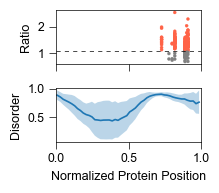

In [13]:
out_file = f'{ANALYSIS_DIR}/al2_positional.csv'
if not os.path.isfile(out_file):
    tmp_df = go_df[go_df['Description'].apply(lambda x: 'Geminivirus AL2 protein' in x)].copy()
    tmp_df = tmp_df.melt(id_vars=['tile_ID','norm_pos','is_activator'],value_vars=['ratio_rep1','ratio_rep2'])
    tmp_df['tile_pos'] = tmp_df['tile_ID'].apply(lambda x: int(x.split('-')[-1]))
    tmp_df['protein_ID'] = tmp_df['tile_ID'].apply(lambda x: '-'.join(x.split('-')[:-1]))
    tmp_df['is_activator'] = tmp_df['value'] > ACTIVATOR_MIN
    x = tmp_df.merge(protein_df,on='protein_ID')[['protein_ID','aa_seq']].drop_duplicates()
    with open(f'{ANALYSIS_DIR}/al2.faa','w') as faa_file:
        for idx, row in x.iterrows():
            faa_file.write(f'>{row["protein_ID"]}\n{row["aa_seq"]}\n')
    tmp_df.to_csv(out_file,index=False)
else:
    tmp_df = pd.read_csv(out_file)
df = parse_metapredict(f'{ANALYSIS_DIR}/al2_disorder_scores.csv')
smoothed = make_long_df(df)

fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(2.3,2),sharex=True)
g = sns.scatterplot(data=tmp_df,x='norm_pos',y='value',hue='is_activator',edgecolor=None,s=5, palette=['grey','tomato'],ax=ax[0])
g.set(xlabel='Normalized Protein Position',ylabel='Ratio',xlim=[0,1])
xmin,xmax = g.get_xlim()
line = g.axhline(y=ACTIVATOR_MIN,xmin=xmin,xmax=xmax,linewidth=0.5,linestyle='--',color='black')
line.set_dashes([6, 6])
g.legend().remove()
g = sns.lineplot(data=smoothed, x='norm_pos', y='mean_value',ax=ax[1])
ax[1].fill_between(smoothed['norm_pos'], 
                 smoothed['mean_value'] - smoothed['sd'], 
                 smoothed['mean_value'] + smoothed['sd'], 
                 alpha=0.3)
g.set(ylabel='Disorder')
plt.xlabel('Normalized Protein Position')
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-al2_proteins.svg',**FIG_PARAMS)

# position of RNA polymerase activators/repressors wrt protein sequence


/data/lucas/01-experiments/eLW044-simon_magnets/03-CODE/utils.py:474: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smoothed = long_df.groupby('bin').agg(


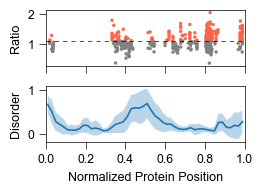

In [14]:
out_file = f'{ANALYSIS_DIR}/rnadirected_positional.csv'
if not os.path.isfile(out_file):
    tmp_df = go_df[go_df['Description'].apply(lambda x: 'rna-directed' in x.lower())].copy()
    tmp_df = tmp_df.melt(id_vars=['tile_ID','norm_pos','is_activator'],value_vars=['ratio_rep1','ratio_rep2'])
    tmp_df['is_activator'] = tmp_df['value'] > ACTIVATOR_MIN
    tmp_df['tile_pos'] = tmp_df['tile_ID'].apply(lambda x: int(x.split('-')[-1]))
    tmp_df['protein_ID'] = tmp_df['tile_ID'].apply(lambda x: '-'.join(x.split('-')[:-1]))
    x = tmp_df.merge(protein_df,on='protein_ID')[['protein_ID','aa_seq']].drop_duplicates()
    with open(f'{ANALYSIS_DIR}/rnadirected.faa','w') as faa_file:
        for idx, row in x.iterrows():
            faa_file.write(f'>{row["protein_ID"]}\n{row["aa_seq"]}\n')
    tmp_df.to_csv(out_file,index=False)
else:
    tmp_df = pd.read_csv(out_file)

df = parse_metapredict(f'{ANALYSIS_DIR}/rnadirected_disorder_scores.csv')
smoothed = make_long_df(df)

fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(2.7,2),sharex=True)

g = sns.scatterplot(data=tmp_df,x='norm_pos',y='value',hue='is_activator',edgecolor=None,s=5, palette=['grey','tomato'],ax=ax[0])
g.set(xlabel='Normalized protein position',ylabel='Ratio',xlim=[0,1])
xmin,xmax = g.get_xlim()
line = g.axhline(y=ACTIVATOR_MIN,xmin=xmin,xmax=xmax,linewidth=0.5,linestyle='--',color='black')
line.set_dashes([6, 6])
g.legend().remove()

g = sns.lineplot(data=smoothed, x='norm_pos', y='mean_value',ax=ax[1])
ax[1].fill_between(smoothed['norm_pos'], 
                 smoothed['mean_value'] - smoothed['sd'], 
                 smoothed['mean_value'] + smoothed['sd'], 
                 alpha=0.3)

g.set(ylabel='Disorder')
plt.xlabel('Normalized Protein Position')
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-rnadirected_proteins.svg',**FIG_PARAMS)

/data/lucas/01-experiments/eLW044-simon_magnets/03-CODE/utils.py:474: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smoothed = long_df.groupby('bin').agg(


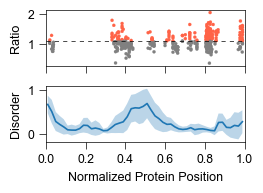

In [15]:
out_file = f'{ANALYSIS_DIR}/polymerase_positional.csv'
if os.path.isfile(out_file):
    tmp_df = go_df[go_df['Description'].apply(lambda x: 'rna-directed' in x.lower())].copy()
    tmp_df = tmp_df.melt(id_vars=['tile_ID','norm_pos','is_activator'],value_vars=['ratio_rep1','ratio_rep2'])
    tmp_df['is_activator'] = tmp_df['value'] > ACTIVATOR_MIN
    tmp_df['tile_pos'] = tmp_df['tile_ID'].apply(lambda x: int(x.split('-')[-1]))
    tmp_df['protein_ID'] = tmp_df['tile_ID'].apply(lambda x: '-'.join(x.split('-')[:-1]))
    x = tmp_df.merge(protein_df,on='protein_ID')[['protein_ID','aa_seq']].drop_duplicates()
    with open(f'{ANALYSIS_DIR}/polymerase.faa','w') as faa_file:
        for idx, row in x.iterrows():
            faa_file.write(f'>{row["protein_ID"]}\n{row["aa_seq"]}\n')
    tmp_df.to_csv(out_file,index=False)
else:
    tmp_df = pd.read_csv(out_file)

df = parse_metapredict(f'{ANALYSIS_DIR}/rnadirected_disorder_scores.csv')
smoothed = make_long_df(df)

fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(2.7,2),sharex=True)

g = sns.scatterplot(data=tmp_df,x='norm_pos',y='value',hue='is_activator',edgecolor=None,s=5, palette=['grey','tomato'],ax=ax[0])
g.set(xlabel='Normalized protein position',ylabel='Ratio',xlim=[0,1])
xmin,xmax = g.get_xlim()
line = g.axhline(y=ACTIVATOR_MIN,xmin=xmin,xmax=xmax,linewidth=0.5,linestyle='--',color='black')
line.set_dashes([6, 6])
g.legend().remove()

g = sns.lineplot(data=smoothed, x='norm_pos', y='mean_value',ax=ax[1])
ax[1].fill_between(smoothed['norm_pos'], 
                 smoothed['mean_value'] - smoothed['sd'], 
                 smoothed['mean_value'] + smoothed['sd'], 
                 alpha=0.3)

g.set(ylabel='Disorder')
plt.xlabel('Normalized Protein Position')
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-rnadirected_proteins.svg',**FIG_PARAMS)

# position of helical viral capsid activators/repressors wrt protein sequence

/data/lucas/01-experiments/eLW044-simon_magnets/03-CODE/utils.py:474: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smoothed = long_df.groupby('bin').agg(


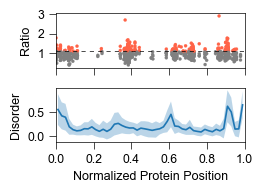

In [16]:
out_file = f'{ANALYSIS_DIR}/capsid_positional.csv'
if not os.path.isfile(out_file):
    tmp_df = go_df[go_df['Description'].apply(lambda x: 'capsid' in x.lower())].copy()
    tmp_df = tmp_df.melt(id_vars=['tile_ID','norm_pos','is_activator'],value_vars=['ratio_rep1','ratio_rep2'])
    tmp_df['is_activator'] = tmp_df['value'] > ACTIVATOR_MIN
    tmp_df['tile_pos'] = tmp_df['tile_ID'].apply(lambda x: int(x.split('-')[-1]))
    tmp_df['protein_ID'] = tmp_df['tile_ID'].apply(lambda x: '-'.join(x.split('-')[:-1]))
    x = tmp_df.merge(protein_df,on='protein_ID')[['protein_ID','aa_seq']].drop_duplicates()
    with open(f'{ANALYSIS_DIR}/capsid.faa','w') as faa_file:
        for idx, row in x.iterrows():
            faa_file.write(f'>{row["protein_ID"]}\n{row["aa_seq"]}\n')
    tmp_df.to_csv(out_file,index=False)
else:
    tmp_df = pd.read_csv(out_file)

df = parse_metapredict(f'{ANALYSIS_DIR}/capsid_disorder_scores.csv')
smoothed = make_long_df(df)

fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(2.7,2),sharex=True)
g = sns.scatterplot(data=tmp_df,x='norm_pos',y='value',hue='is_activator',edgecolor=None,s=5, palette=['grey','tomato'],ax=ax[0])
g.set(xlabel='Normalized Protein Position',ylabel='Ratio',xlim=[0,1])
xmin,xmax = g.get_xlim()
line = g.axhline(y=ACTIVATOR_MIN,xmin=xmin,xmax=xmax,linewidth=0.5,linestyle='--',color='black')
line.set_dashes([6, 6])
g.legend().remove()
g = sns.lineplot(data=smoothed, x='norm_pos', y='mean_value',ax=ax[1])
ax[1].fill_between(smoothed['norm_pos'], 
                 smoothed['mean_value'] - smoothed['sd'], 
                 smoothed['mean_value'] + smoothed['sd'], 
                 alpha=0.3)
g.set(ylabel='Disorder')
plt.xlabel('Normalized Protein Position')
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-capsid_proteins.svg',**FIG_PARAMS)

/data/lucas/01-experiments/eLW044-simon_magnets/03-CODE/utils.py:474: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smoothed = long_df.groupby('bin').agg(


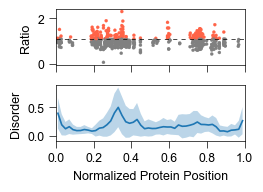

In [17]:
out_file = f'{ANALYSIS_DIR}/helicase_positional.csv'
if not os.path.isfile(out_file):
    tmp_df = go_df[go_df['Description'].apply(lambda x: 'helicase' in x.lower())].copy()
    tmp_df = tmp_df.melt(id_vars=['tile_ID','norm_pos','is_activator'],value_vars=['ratio_rep1','ratio_rep2'])
    tmp_df['is_activator'] = tmp_df['value'] > ACTIVATOR_MIN
    tmp_df['tile_pos'] = tmp_df['tile_ID'].apply(lambda x: int(x.split('-')[-1]))
    tmp_df['protein_ID'] = tmp_df['tile_ID'].apply(lambda x: '-'.join(x.split('-')[:-1]))
    x = tmp_df.merge(protein_df,on='protein_ID')[['protein_ID','aa_seq']].drop_duplicates()
    with open(f'{ANALYSIS_DIR}/helicase.faa','w') as faa_file:
        for idx, row in x.iterrows():
            faa_file.write(f'>{row["protein_ID"]}\n{row["aa_seq"]}\n')
    tmp_df.to_csv(out_file,index=False)
else:
    tmp_df = pd.read_csv(out_file)

df = parse_metapredict(f'{ANALYSIS_DIR}/helicase_disorder_scores.csv')
smoothed = make_long_df(df)

fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(2.7,2),sharex=True)
g = sns.scatterplot(data=tmp_df,x='norm_pos',y='value',hue='is_activator',edgecolor=None,s=5, palette=['grey','tomato'],ax=ax[0])
g.set(xlabel='Normalized Protein Position',ylabel='Ratio',xlim=[0,1])
xmin,xmax = g.get_xlim()
line = g.axhline(y=ACTIVATOR_MIN,xmin=xmin,xmax=xmax,linewidth=0.5,linestyle='--',color='black')
line.set_dashes([6, 6])
g.legend().remove()
g = sns.lineplot(data=smoothed, x='norm_pos', y='mean_value',ax=ax[1])
ax[1].fill_between(smoothed['norm_pos'], 
                 smoothed['mean_value'] - smoothed['sd'], 
                 smoothed['mean_value'] + smoothed['sd'], 
                 alpha=0.3)
g.set(ylabel='Disorder')
plt.xlabel('Normalized Protein Position')
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-helicase_proteins.svg',**FIG_PARAMS)

# analyze protein descriptors from interproscan

<Axes: xlabel='max_ratio', ylabel='Description'>

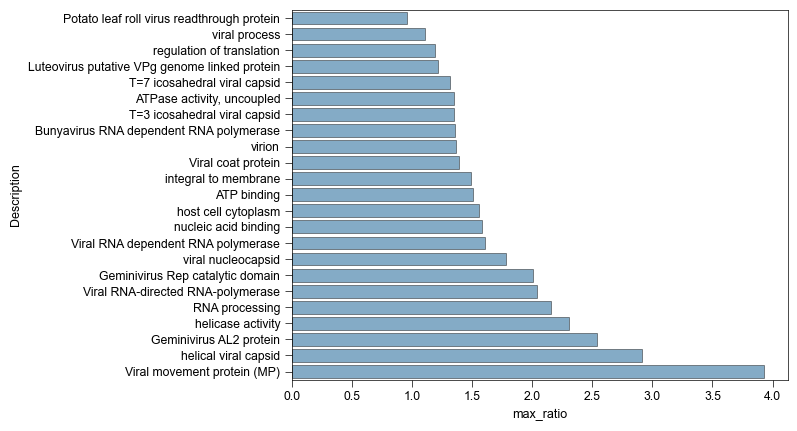

In [18]:
tile_df = pd.read_csv(f'{TILE_DIR}/viral_tiles.csv')
predictions_df = pd.read_csv(f'{INFERENCE_DIR}/01-PADDLE/PADDLE_predictions.csv').drop(columns='tile_ID')
query_df = tile_df.merge(predictions_df,on=['tile']).reset_index(drop=True)
query_df['zscore'] = query_df['zscore'].astype(float)
protein_df = pd.read_csv(f'{TILE_DIR}/viral_proteins_clustered90.csv')
ncbi_df = pd.read_csv(f'{VIRUS_DIR}/plant_virus_metadata.csv')
library_df = query_df.drop_duplicates(subset='tile').merge(ncbi_df,left_on='genome',right_on='Filename')
genbank_accessions = list(library_df['accession'].unique())
tax_ids = pd.read_csv(f'{METADATA_DIR}/tax_ids_all.csv')
tax_mapper = dict(zip(genbank_accessions,tax_ids['0']))
library_df['tax_id'] = library_df['accession'].map(tax_mapper)
library_df['family'] = library_df['tax_id'].apply(lambda x: get_taxonomic_family(x))

data_df = pd.read_csv(f'{ANALYSIS_DIR}/experimental_data_fitted.csv')
data_df = data_df[data_df['tile_ID'].apply(lambda x: len(x.split('-')) > 1)] # remove controls
cols = ['query','seed_ortholog','evalue','score','eggNOG_OGs','max_annot_lvl','COG_category','Description','Preferred_name','GOs','EC','KEGG_ko','KEGG_Pathway','KEGG_Module','KEGG_Reaction','KEGG_rclass','BRITE','KEGG_TC','CAZy','BiGG_Reaction','PFAMs']
eggnog_df = pd.read_csv(f'{ANALYSIS_DIR}/eggnog_mapper_results.tsv',sep='\t',comment='#',names=cols)
eggnog_df = eggnog_df.replace('-',np.nan).dropna(axis=1, how='all')
go_df = data_df.merge(eggnog_df,left_on='protein_id',right_on='query')
len_map = tile_df.groupby('protein_ID')['tile_count'].agg(lambda x: int(max(x))+1).to_dict()
go_df['protein_ID'] = go_df['tile_ID'].apply(lambda x: '-'.join(x.split('-')[:-1]))
go_df['position'] = go_df['tile_ID'].apply(lambda x: int(x.split('-')[-1]))
go_df['protein_len'] = go_df['protein_ID'].map(len_map)
go_df['norm_pos'] = go_df['position']/go_df['protein_len']
go_df = go_df.dropna(subset='Description')

go_df['max_ratio'] = go_df.query('ratio_rep2 < 10')[['ratio_rep1', 'ratio_rep2']].max(axis=1)
tmp_df = go_df.groupby('Description')['max_ratio'].max().reset_index()
sns.barplot(data=tmp_df.sort_values('max_ratio'),y='Description',x='max_ratio',alpha=0.6,edgecolor='black',linewidth=0.5)

In [19]:
MAKE_FASTA = False
if MAKE_FASTA:
    with open(f'{ANALYSIS_DIR}/viral_proteins.faa','w') as out_file:
        for _,row in protein_df.iterrows():
            out_file.write(f'>{row["protein_ID"]}\n{row["aa_seq"]}\n')
    tmp_df = protein_df[protein_df['description'].isin(library_df.query('family == "Geminiviridae"')['protein_ID'].unique())]  # 1379 -> 1379
    with open(f'{ANALYSIS_DIR}/geminivirus.faa','w') as out_file:
        for _,row in tmp_df.iterrows():
            out_file.write(f'>{row["description"]}\n{row["aa_seq"]}\n')

In [ ]:
RUN_INTERPROSCAN = False
if RUN_INTERPROSCAN:
    os.system(f'~/Documents/code/interproscan-5.73-104.0/interproscan.sh -i {ANALYSIS_DIR}/geminivirus.faa -f tsv -o {ANALYSIS_DIR}/geminivirus_interproscan.tsv')
    os.system(f'~/Documents/code/interproscan-5.73-104.0/interproscan.sh -i {ANALYSIS_DIR}/seqs.faa -f tsv -o {ANALYSIS_DIR}/seqs_interproscan.tsv')

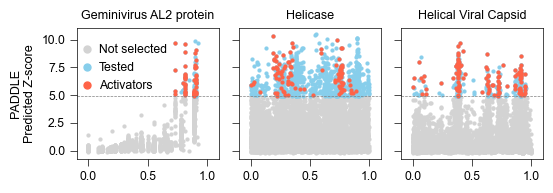

In [26]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(5.5, 2), sharey=True)
targets = [
    {
        'keyword': 'AL2',
        'positional_file': f'{ANALYSIS_DIR}/al2_positional.csv',
        'title': 'Geminivirus AL2 protein'
    },
    {
        'keyword': 'helicase',
        'positional_file': f'{ANALYSIS_DIR}/helicase_positional.csv',
        'title': 'Helicase'
    },
    {
        'keyword': 'helical viral capsid',
        'positional_file': f'{ANALYSIS_DIR}/capsid_positional.csv',
        'title': 'Helical Viral Capsid'
    }
]

for i, target in enumerate(targets):
    interpro_df = load_interproscan(f'{ANALYSIS_DIR}/viral_proteins_interproscan.tsv')
    filtered_df = filter_proteins(interpro_df, go_df, target['keyword'])
    tmp_df = prepare_tmp_df(library_df, filtered_df['Protein_ID'])
    plot_panel(axes[i], tmp_df, target['positional_file'], target['title'])
axes[0].set_ylabel('PADDLE\nPredicted Z-score')
legend_handles = [
    Line2D([0], [0], marker='o', color='lightgrey', label='Not selected', markersize=5, linestyle='None'),
    Line2D([0], [0], marker='o', color='skyblue', label='Tested', markersize=5, linestyle='None'),
    Line2D([0], [0], marker='o', color='tomato', label='Activators', markersize=5, linestyle='None')
]
axes[0].legend(handles=legend_handles, loc=(-0.05, 0.475), frameon=False, handletextpad=0)

plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-top3_go_term_positional.svg',**FIG_PARAMS)

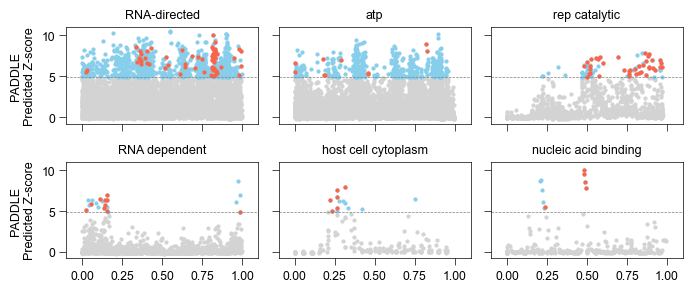

In [22]:
out_file = f'{ANALYSIS_DIR}/na_binding_positional.csv'
if not os.path.isfile(out_file):
    tmp_df = go_df[go_df['Description'].apply(lambda x: 'nucleic acid binding' in x.lower())].copy()
    tmp_df = tmp_df.melt(id_vars=['tile_ID','norm_pos','is_activator'],value_vars=['ratio_rep1','ratio_rep2'])
    tmp_df['is_activator'] = tmp_df['value'] > ACTIVATOR_MIN
    tmp_df['tile_pos'] = tmp_df['tile_ID'].apply(lambda x: int(x.split('-')[-1]))
    tmp_df['protein_ID'] = tmp_df['tile_ID'].apply(lambda x: x.split('-')[0])
    x = tmp_df.merge(protein_df,on='protein_ID')[['protein_ID','aa_seq']].drop_duplicates()
    tmp_df.to_csv(out_file,index=False)
else:
    tmp_df = pd.read_csv(out_file)
tmp_df

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7, 3), sharey=True, sharex=True)

targets = ['RNA-directed', 'atp', 'rep catalytic', 'RNA dependent', 'host cell cytoplasm', 'nucleic acid binding']
positonal_files = [
         f'{ANALYSIS_DIR}/rnadirected_positional.csv',
         f'{ANALYSIS_DIR}/atp_positional.csv',
         f'{ANALYSIS_DIR}/rep_catalytic_positional.csv',
         f'{ANALYSIS_DIR}/rna_dependent_positional.csv',
         f'{ANALYSIS_DIR}/host_cell_cytoplasm_positional.csv',
         f'{ANALYSIS_DIR}/na_binding_positional.csv'
]
axes = axes.flatten()

for i, target in enumerate(targets):
    interpro_df = load_interproscan(f'{ANALYSIS_DIR}/viral_proteins_interproscan.tsv')
    filtered_df = filter_proteins(interpro_df, go_df, target)
    tmp_df = prepare_tmp_df(library_df, filtered_df['Protein_ID'])
    plot_panel(axes[i], tmp_df, positonal_files[i], target)
    axes[i].set_ylabel('PADDLE\nPredicted Z-score')

for j in range(len(targets), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-remaining_go_term_positional.svg',**FIG_PARAMS)

/data/lucas/01-experiments/eLW044-simon_magnets/03-CODE/utils.py:474: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smoothed = long_df.groupby('bin').agg(
/data/lucas/01-experiments/eLW044-simon_magnets/03-CODE/utils.py:474: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smoothed = long_df.groupby('bin').agg(
/data/lucas/01-experiments/eLW044-simon_magnets/03-CODE/utils.py:474: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


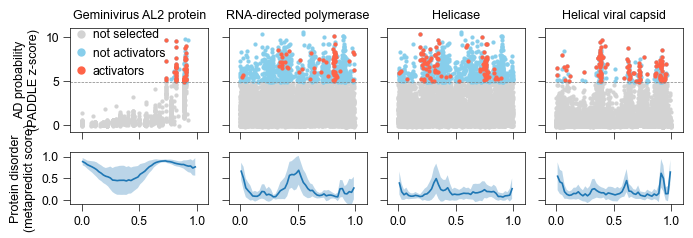

In [24]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(7, 2.45), sharey='row',sharex=True,gridspec_kw={'height_ratios': [2, 1]})
targets = [
    {
        'keyword': 'AL2',
        'positional_file': f'{ANALYSIS_DIR}/al2_positional.csv',
        'disorder_file':f'{ANALYSIS_DIR}/al2_disorder_scores.csv',
        'title': 'Geminivirus AL2 protein'
    },
    {
        'keyword': 'RNA-directed',
        'positional_file': f'{ANALYSIS_DIR}/rnadirected_positional.csv',
        'disorder_file':f'{ANALYSIS_DIR}/rnadirected_disorder_scores.csv',
        'title': 'RNA-directed polymerase'
    },
    {
        'keyword': 'helicase',
        'positional_file': f'{ANALYSIS_DIR}/helicase_positional.csv',
        'disorder_file':f'{ANALYSIS_DIR}/helicase_disorder_scores.csv',
        'title': 'Helicase'
    },
    {
        'keyword': 'helical viral capsid',
        'positional_file': f'{ANALYSIS_DIR}/capsid_positional.csv',
        'disorder_file':f'{ANALYSIS_DIR}/capsid_disorder_scores.csv',
        'title': 'Helical viral capsid'
    }
]

for i, target in enumerate(targets):
    interpro_df = load_interproscan(f'{ANALYSIS_DIR}/viral_proteins_interproscan.tsv')
    filtered_df = filter_proteins(interpro_df, go_df, target['keyword'])
    tmp_df = prepare_tmp_df(library_df, filtered_df['Protein_ID'])
    plot_panel(axes[0,i], tmp_df, target['positional_file'], target['title'])
    smoothed = make_long_df(parse_metapredict(target['disorder_file']))
    g = sns.lineplot(data=smoothed, x='norm_pos', y='mean_value',ax=axes[1,i])
    axes[1,i].fill_between(smoothed['norm_pos'], 
                    smoothed['mean_value'] - smoothed['sd'], 
                    smoothed['mean_value'] + smoothed['sd'], 
                    alpha=0.3)
    axes[1,i].set_xlabel(None)
axes[0,0].set_ylabel('AD probability\n(PADDLE z-score)')
axes[1,0].set_ylabel('Protein disorder\n(metapredict score)')
axes[1,0].set_ylim(-0.1,1.1)
axes[1,0].yaxis.set_major_locator(MultipleLocator(0.5))
legend_handles = [
    Line2D([0], [0], marker='o', color='lightgrey', label='not selected', markersize=5, linestyle='None'),
    Line2D([0], [0], marker='o', color='skyblue', label='not activators', markersize=5, linestyle='None'),
    Line2D([0], [0], marker='o', color='tomato', label='activators', markersize=5, linestyle='None')
]
axes[0,0].legend(handles=legend_handles, loc=(-0.05, 0.475), frameon=False, handletextpad=0)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-top4_go_term_positional.svg',**FIG_PARAMS)

In [25]:
out_file = f'{ANALYSIS_DIR}/all_lineages.csv'
if not os.path.isfile(out_file):
    def get_genome_type(tax_id):
        handle = Entrez.efetch(db="taxonomy", id=tax_id, retmode="xml")
        records = Entrez.read(handle)
        if len(records) > 0:
            lineage = records[0]["Lineage"]
        else:
            lineage = np.nan
        return lineage

    genome_types = {}
    for tax_id in tqdm(list(tax_ids['0'])):
        genome_types[tax_id] = get_genome_type(tax_id)

    lineage_df = pd.DataFrame([genome_types]).T.reset_index()
    lineage_df.columns = ['tax_id','lineage']
    lineage_df.to_csv(out_file,index=False)

family_to_genome = {
    'Geminiviridae': 'ssDNA',
    'Betaflexiviridae': 'ssRNA(+)',
    'Closteroviridae': 'ssRNA(+)',
    'Potyviridae': 'ssRNA(+)',
    'Solemoviridae': 'ssRNA(+)',
    'Alphasatellitidae': 'ssDNA',
    'Tolecusatellitidae': 'ssDNA',
    'Caulimoviridae': 'dsDNA',
    'Rhabdoviridae': 'ssRNA(-)',
    'Tymoviridae': 'ssRNA(+)',
    'Alphaflexiviridae': 'ssRNA(+)',
    'Amalgaviridae': 'dsRNA',
    'Tombusviridae': 'ssRNA(+)',
    'Family not found': 'Unknown',
    'Secoviridae': 'ssRNA(+)',
    'Endornaviridae': 'dsRNA',
    'Virgaviridae': 'ssRNA(+)',
    'Genomoviridae': 'ssDNA',
    'Mitoviridae': 'ssRNA(+)',
    'Tospoviridae': 'ssRNA(-)',
    'Totiviridae': 'dsRNA',
    'Aspiviridae': 'ssRNA(-)',
    'Deltaflexiviridae': 'ssRNA(+)',
    'Nanoviridae': 'ssDNA',
    'Amesuviridae': 'ssRNA(+)'}
library_df['genome_structure'] = library_df['family'].map(family_to_genome)
library_df[['tax_id','genome_structure']].drop_duplicates().to_csv(f'{ANALYSIS_DIR}/genome_structures_all.csv',index=False)
library_df.head()

,protein_ID,genome,accession,tile_count,tile,tile_ID,activation,zscore,Genome,Accession,...,Number of proteins,Genome Neighbors,Host,Date completed,Date updated,realm,Filename,tax_id,family,genome_structure
0,D1Q61_gp2,Abutilon_golden_mosaic_Yucatan_virus,NC_038438,0,MDSRTGELITARQAENGVYIWEIENPLYFKMYRVEDPMYTRTRVYS...,D1Q61_gp2-000,1.016076,0.039129,Abutilon golden mosaic Yucatan virus,NC_038438,...,5,-,land plants,08/24/2018,08/24/2018,Monodnaviria,Abutilon_golden_mosaic_Yucatan_virus,1312723,Geminiviridae,ssDNA
1,D1Q61_gp2,Abutilon_golden_mosaic_Yucatan_virus,NC_038438,1,ARQAENGVYIWEIENPLYFKMYRVEDPMYTRTRVYSIQIRFNHNLR...,D1Q61_gp2-001,0.974494,-0.063394,Abutilon golden mosaic Yucatan virus,NC_038438,...,5,-,land plants,08/24/2018,08/24/2018,Monodnaviria,Abutilon_golden_mosaic_Yucatan_virus,1312723,Geminiviridae,ssDNA
2,D1Q61_gp2,Abutilon_golden_mosaic_Yucatan_virus,NC_038438,2,WEIENPLYFKMYRVEDPMYTRTRVYSIQIRFNHNLRRALHLHKAYL...,D1Q61_gp2-002,0.993057,-0.017096,Abutilon golden mosaic Yucatan virus,NC_038438,...,5,-,land plants,08/24/2018,08/24/2018,Monodnaviria,Abutilon_golden_mosaic_Yucatan_virus,1312723,Geminiviridae,ssDNA
3,D1Q61_gp2,Abutilon_golden_mosaic_Yucatan_virus,NC_038438,3,MYRVEDPMYTRTRVYSIQIRFNHNLRRALHLHKAYLNFQVWTTSMT...,D1Q61_gp2-003,0.976447,-0.058480,Abutilon golden mosaic Yucatan virus,NC_038438,...,5,-,land plants,08/24/2018,08/24/2018,Monodnaviria,Abutilon_golden_mosaic_Yucatan_virus,1312723,Geminiviridae,ssDNA
4,D1Q61_gp2,Abutilon_golden_mosaic_Yucatan_virus,NC_038438,4,RTRVYSIQIRFNHNLRRALHLHKAYLNFQVWTTSMTASGSTYLARF...,D1Q61_gp2-004,1.018098,0.044007,Abutilon golden mosaic Yucatan virus,NC_038438,...,5,-,land plants,08/24/2018,08/24/2018,Monodnaviria,Abutilon_golden_mosaic_Yucatan_virus,1312723,Geminiviridae,ssDNA
